# 07 - GRU benchmark products (`zhangxu0307/time_series_forecasting_pytorch`)

This notebook inspects and adapts the GRU implementation from the local repository `zhangxu0307/time_series_forecasting_pytorch` for the unified M5 benchmark.

Benchmark products:
- `FOODS_3_228_CA_1_validation` (`high_demand_stable`)
- `FOODS_2_044_CA_3_validation` (`intermittent`)
- `HOBBIES_1_133_CA_4_validation` (`low_volume`)

Official protocol:
- `MAX_DAYS = 365`
- `CONTEXT_LENGTH = 28`
- `VAL_DAYS = 28`
- `TEST_DAYS = 28`
- train = `309`, validation = `28`, fit = `337`, test = final `28`


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'gnn_model_comparison':
    ROOT = ROOT.parents[1]
elif ROOT.name == 'notebooks':
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

REPO_ROOT = ROOT / 'time_series_forecasting_pytorch-master' / 'time_series_forecasting_pytorch-master'
OUT_DIR = ROOT / 'reports' / 'gnn_benchmarks' / 'zhangxu_repo_gru_impl1'
REPO_ROOT, OUT_DIR


(WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/time_series_forecasting_pytorch-master/time_series_forecasting_pytorch-master'),
 WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/zhangxu_repo_gru_impl1'))

## Useful repo files identified

- `src/model.py`: defines `GRUModel`
- `src/NN_train.py`: defines `train(...)` and `predict_iteration(...)`
- `src/util.py`: defines `create_multi_ahead_samples(...)`
- `src/ts_loader.py`: defines `Time_Series_Data`
- `src/NN_forecasting.py`: shows the repo forecasting pipeline

Reused with minimal adaptation:
- GRU architecture
- repo-style dataset wrapper
- repo-style training loop with `RMSprop` + `MSELoss`
- repo-style recursive prediction logic

Adapted for fairness:
- fixed chronological split `309 / 28 / 28`
- scaler fit only on train
- fit on `train + validation = 337`
- final recursive forecast on the last `28` days


In [2]:
from src.experiments.run_zhangxu_repo_gru_benchmark import main

main()


[RUN] FOODS_3_228_CA_1_validation | loss=0.020599 | mae=2.669856 | vr=0.639439 | flat=non-flat
[RUN] FOODS_2_044_CA_3_validation | loss=0.036853 | mae=1.143966 | vr=0.050869 | flat=flat
[RUN] HOBBIES_1_133_CA_4_validation | loss=0.013650 | mae=0.036809 | vr=0.000000 | flat=flat
[OK] Saved metrics -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\zhangxu_repo_gru_impl1\metrics.csv
[OK] Saved training summary -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\zhangxu_repo_gru_impl1\training_summary.csv
[OK] Saved summary -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\zhangxu_repo_gru_impl1\summary.csv
[OK] Saved predictions -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\zhangxu_repo_gru_impl1\predictions.csv


In [3]:
import pandas as pd

training_summary_df = pd.read_csv(OUT_DIR / 'training_summary.csv')
metrics_df = pd.read_csv(OUT_DIR / 'metrics.csv')
summary_df = pd.read_csv(OUT_DIR / 'summary.csv')

training_summary_df


,series_id,benchmark_label,model,epochs,final_loss,context_length,train_days,fit_days
0,FOODS_3_228_CA_1_validation,high_demand_stable,ZhangxuRepoGRU,80,0.020599,28,309,337
1,FOODS_2_044_CA_3_validation,intermittent,ZhangxuRepoGRU,80,0.036853,28,309,337
2,HOBBIES_1_133_CA_4_validation,low_volume,ZhangxuRepoGRU,80,0.013650,28,309,337


In [4]:
summary_df


,series_id,benchmark_label,final_loss,mae,rmse,pred_std,real_std,variance_ratio,trend_correlation,direction_accuracy,shape_similarity,peak_detection_rate,flat_nonflat
0,FOODS_3_228_CA_1_validation,high_demand_stable,0.020599,2.669856,3.146730,1.778805,2.781820,0.639439,0.641938,0.592593,0.701566,1.0,non-flat
1,FOODS_2_044_CA_3_validation,intermittent,0.036853,1.143966,1.495846,0.074109,1.456863,0.050869,0.350760,0.296296,0.717551,0.0,flat
2,HOBBIES_1_133_CA_4_validation,low_volume,0.013650,0.036809,0.037088,0.004538,0.000000,0.000000,NaN,0.000000,0.425688,1.0,flat


WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/zhangxu_repo_gru_impl1/figures/high_demand_stable_FOODS_3_228_CA_1_validation_real_vs_predicted.png')

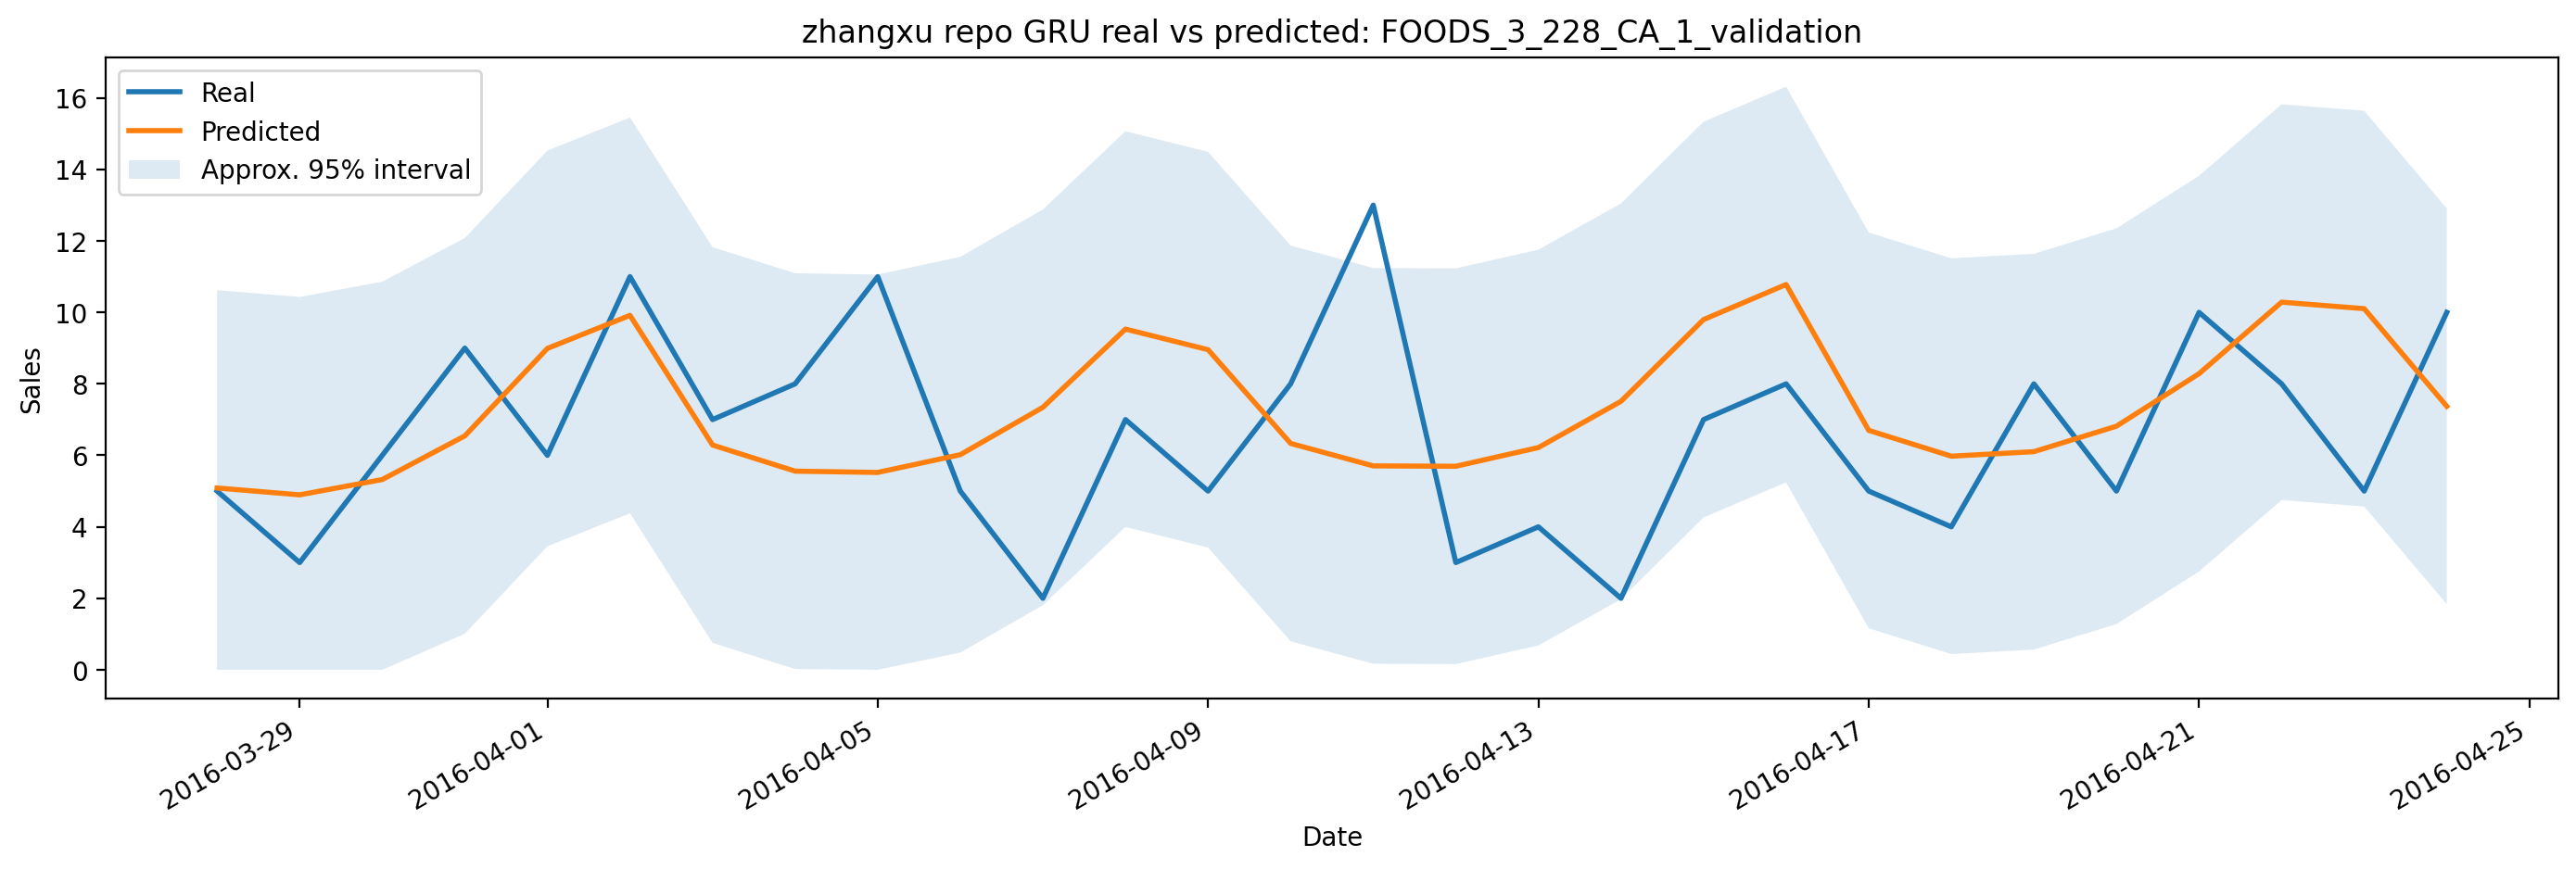

WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/zhangxu_repo_gru_impl1/figures/intermittent_FOODS_2_044_CA_3_validation_real_vs_predicted.png')

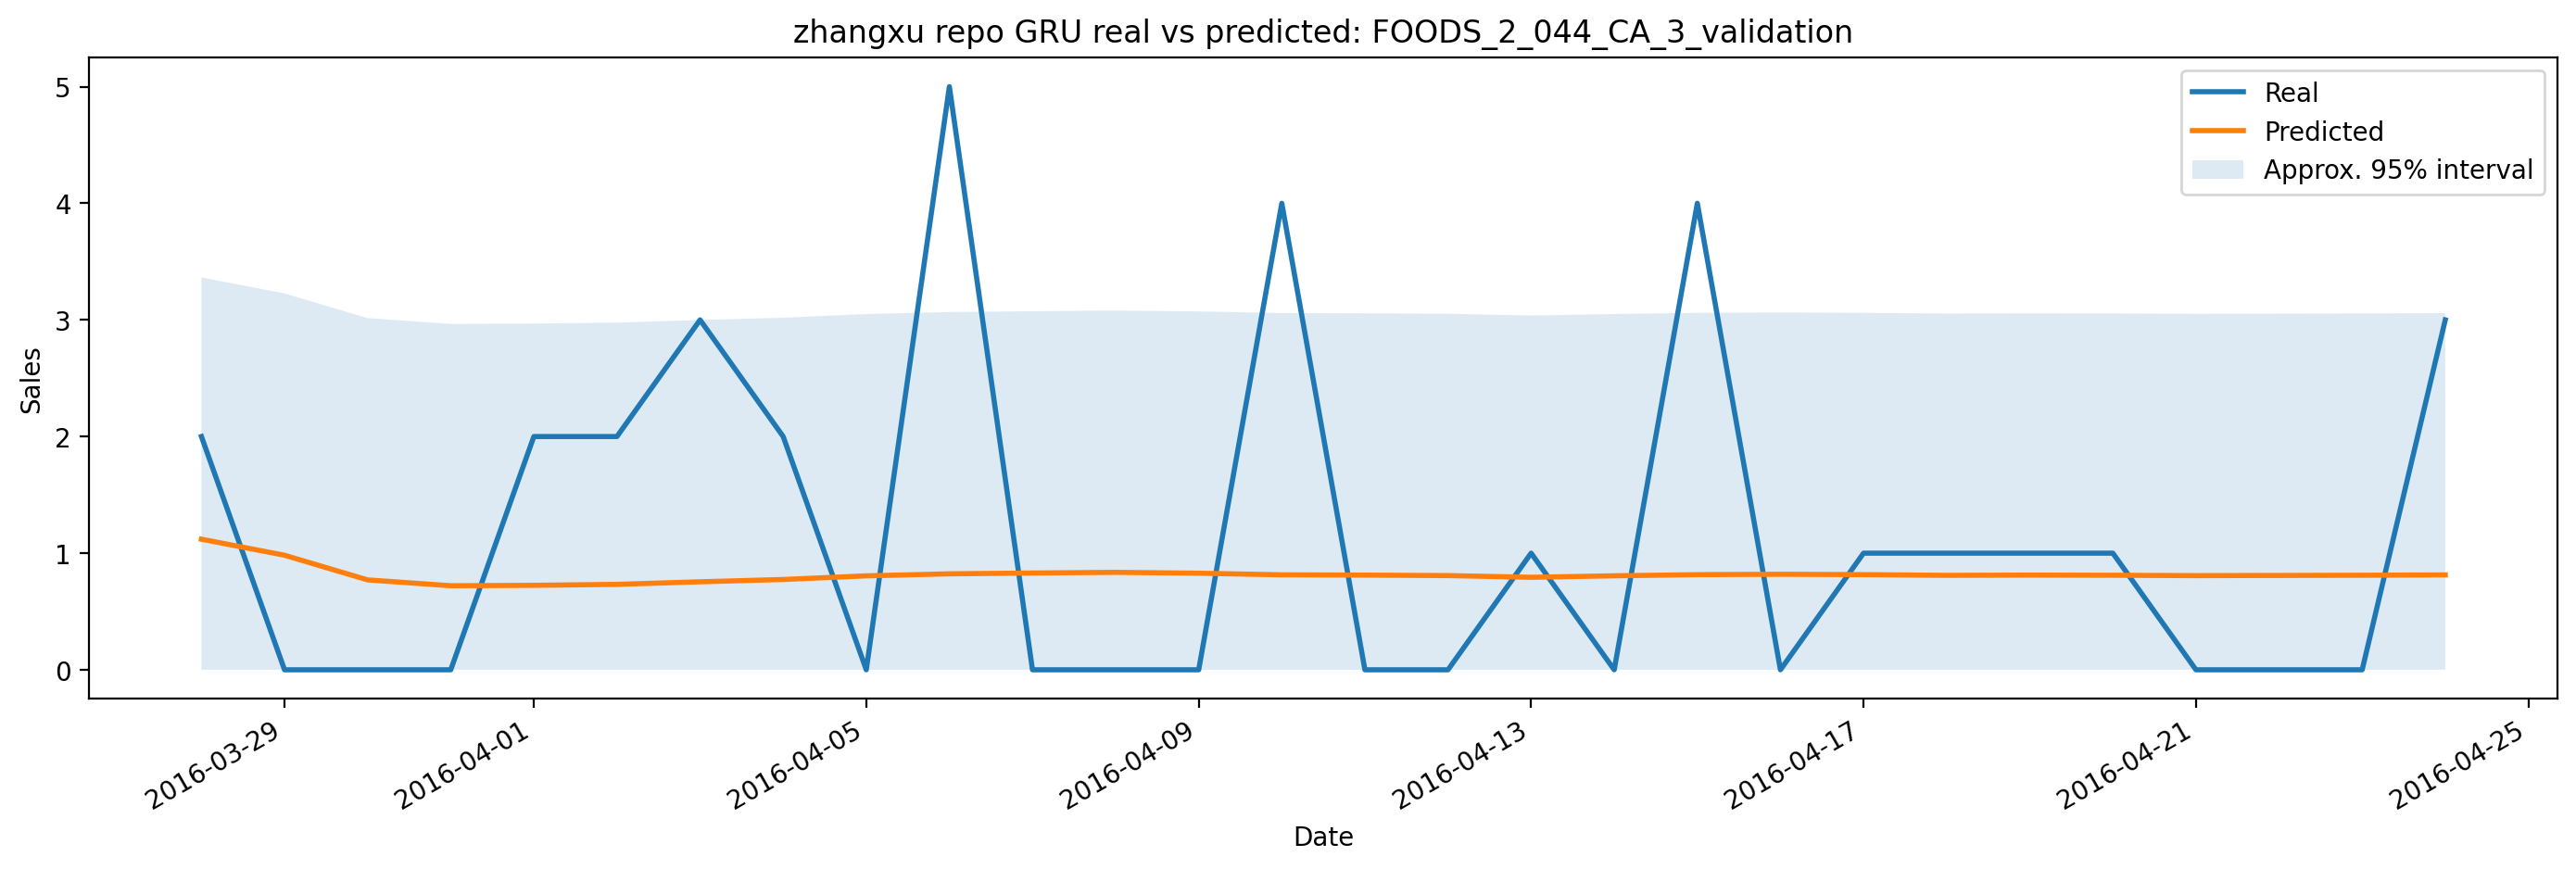

WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/zhangxu_repo_gru_impl1/figures/low_volume_HOBBIES_1_133_CA_4_validation_real_vs_predicted.png')

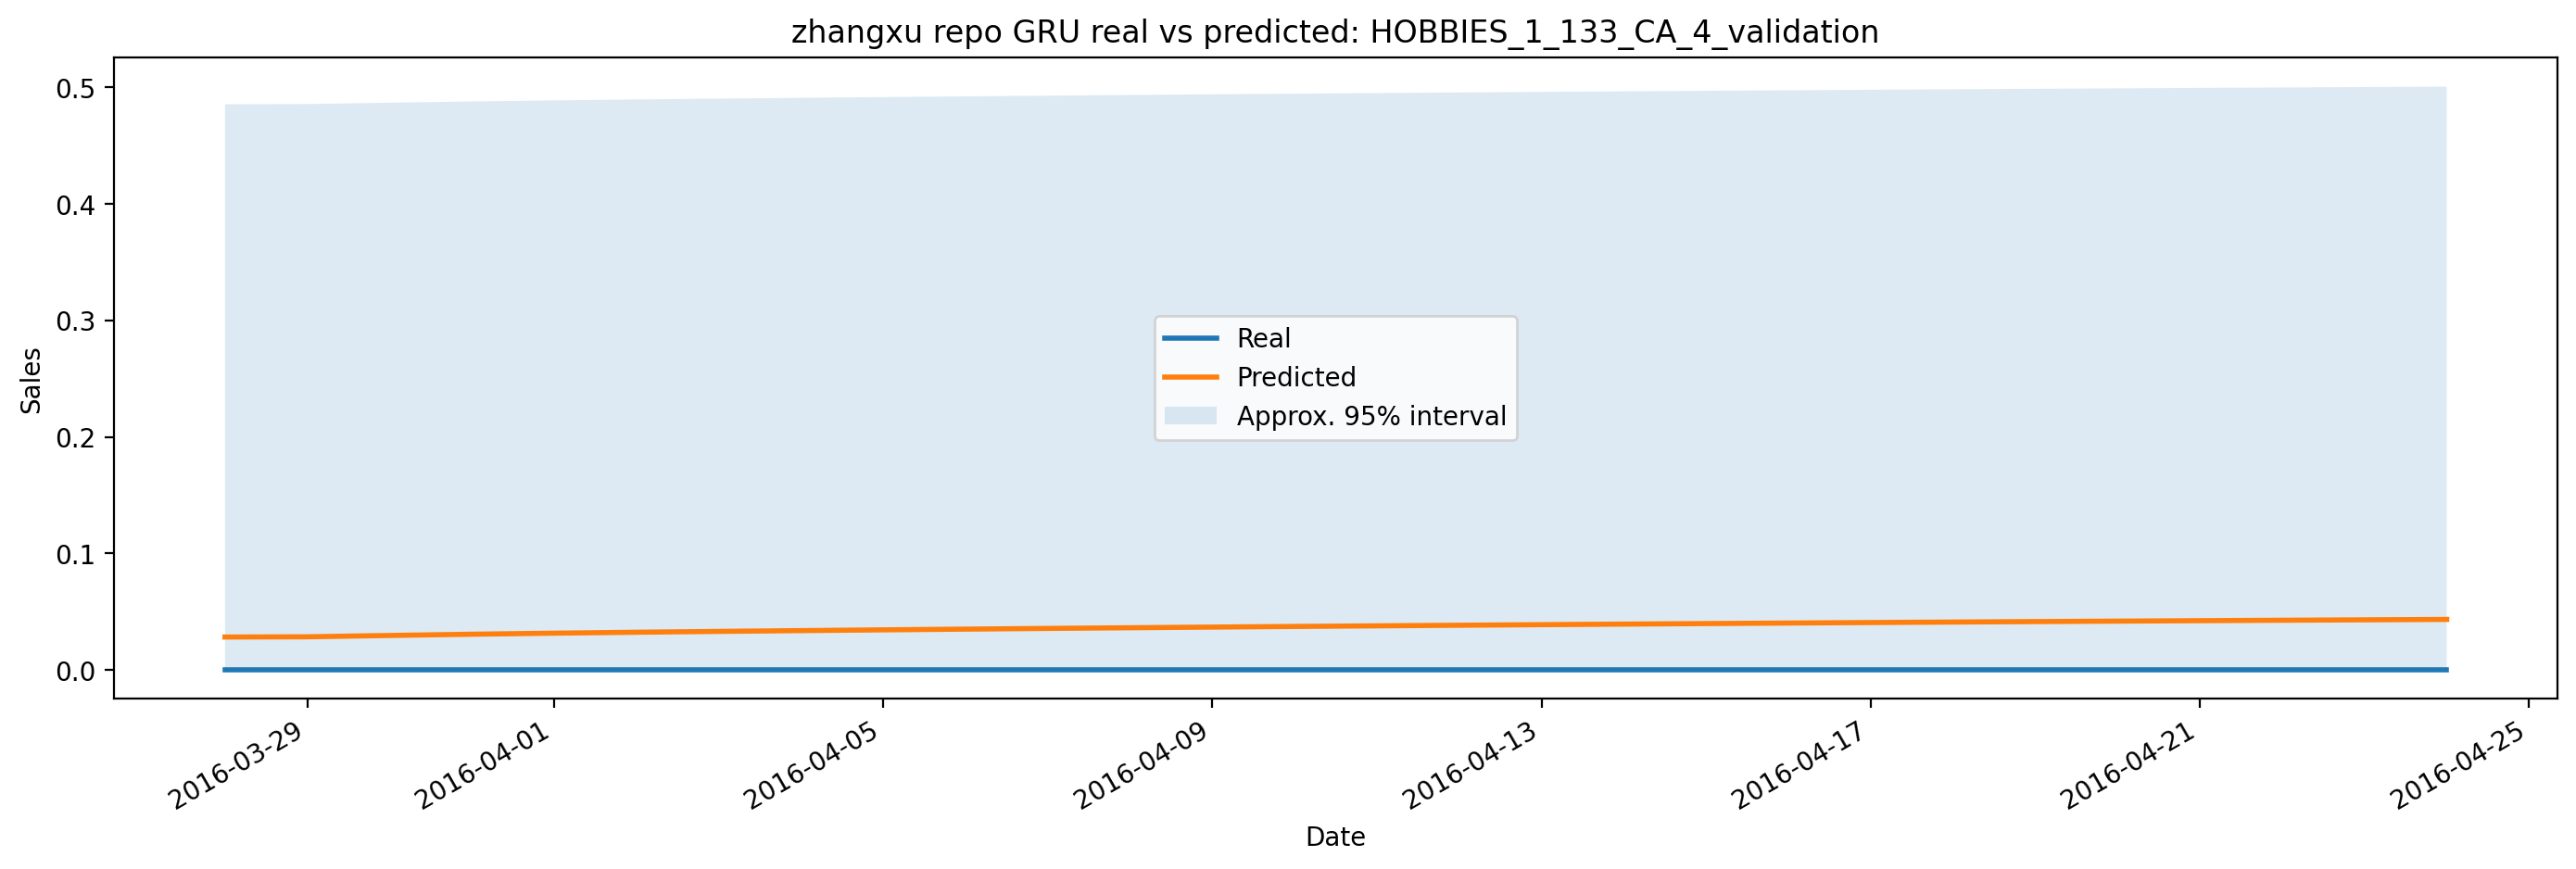

In [5]:
from IPython.display import Image, display

for label, series_id in [
    ('high_demand_stable', 'FOODS_3_228_CA_1_validation'),
    ('intermittent', 'FOODS_2_044_CA_3_validation'),
    ('low_volume', 'HOBBIES_1_133_CA_4_validation'),
]:
    path = OUT_DIR / 'figures' / f'{label}_{series_id}_real_vs_predicted.png'
    display(path)
    display(Image(filename=str(path)))
